<a href="https://colab.research.google.com/github/Suhail-Ahmed7/flyrank-ml-internship-suhail/blob/main/work/notebooks/capstone_refresh_opportunity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ranking Webpages for Next-Month Click Decline

## Google Search Ranking and Discoverability Capstone

**Name:** Suhail Ahmed  
**Track:** Machine Learning  
**Lane:** Refresh / Content Opportunity Scoring

### Research question

Can February search and engagement signals help rank webpages that are
likely to experience lower average daily clicks in March?

### Capstone objective

The objective of this project is to create a ranked decision-support
queue for content teams.

The model does not automatically decide which pages must be refreshed.
Instead, it ranks pages that may deserve further investigation because
their average daily clicks could decline in the following month.

### Main workflow

1. Build February page-level features.
2. Define decline using March average daily clicks.
3. Compare a simple baseline with a Logistic Regression model.
4. Evaluate the model using a client-grouped holdout.
5. Audit the features for leakage.
6. Review real model errors.
7. Produce ranked content-review recommendations.

## 1. Abstract

This capstone examines whether February search and engagement signals can
help prioritize webpages that later experience lower average daily clicks
in March.

The analysis uses 23,703 webpages from 19 anonymized clients. Six
February-only features were evaluated using a client-grouped holdout so
that all four test clients were unseen during training.

A simple February CTR baseline was compared with Logistic Regression. Both
methods achieved 100% Precision@20 and 98% Precision@50. The CTR baseline
achieved slightly higher average precision: 0.8755 compared with 0.8619
for Logistic Regression.

The findings show that the simpler CTR rule performed as well as or better
than the machine-learning model in this grouped holdout. The final output
is therefore a ranked decision-support queue based on February CTR, with
warnings for low-volume pages where CTR may be unstable.

These results are observational and specific to this dataset, validation
split and February-to-March 2026 period.

## 2. Introduction and Problem Statement

Content teams may manage thousands of webpages but have limited time for
manual review. They need a practical way to identify which pages deserve
attention first.

This project asks:

> Can February search and engagement signals help rank webpages that are
> likely to experience lower average daily clicks in March?

The goal is not to automatically decide that a page must be refreshed.
Instead, the project creates a ranked review queue that can help content
teams investigate potentially declining pages efficiently.

The project compares a simple rule-based baseline with an interpretable
machine-learning model. It also checks for leakage, evaluates performance
on unseen clients and reviews concrete model errors before making any
recommendation.

## Notebook Roadmap

1. Title and Abstract
2. Introduction and Problem Statement
3. Data
4. Methodology
5. Results
6. Validation and Leakage Audit
7. Error Analysis
8. Ranked Content Recommendations
9. Limitations and Honest Framing
10. Conclusion
11. Reproducibility
12. Acknowledgements

In [1]:
%pip -q install duckdb huggingface_hub

import duckdb
import numpy as np
import pandas as pd
import sklearn

from google.colab import userdata

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 150)

# Get the Hugging Face token from Colab Secrets.
HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN is missing. Add it in Colab Secrets "
        "and enable notebook access."
    )

# Connect DuckDB to the FlyRank warehouse.
con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

FEB_MAR_TABLE = (
    "read_parquet(["
    f"'{REL}/fact_content_daily_performance/month=2026-02/*.parquet', "
    f"'{REL}/fact_content_daily_performance/month=2026-03/*.parquet'"
    "])"
)

RANDOM_STATE = 42

print("Connected successfully to the FlyRank warehouse.")
print("scikit-learn version:", sklearn.__version__)
print("Random seed:", RANDOM_STATE)

Connected successfully to the FlyRank warehouse.
scikit-learn version: 1.6.1
Random seed: 42


In [2]:
# Build one row per webpage.
# February provides the model features.
# March is used only to create the later decline label.

model_frame = con.execute(
    f"""
    WITH monthly AS (
        SELECT
            client_hash_id,
            content_hash_id,
            month,

            COUNT(
                DISTINCT CASE
                    WHEN gsc_data_available IS TRUE
                    THEN report_date
                END
            ) AS gsc_observed_days,

            COUNT(
                DISTINCT CASE
                    WHEN ga4_data_available IS TRUE
                    THEN report_date
                END
            ) AS ga4_observed_days,

            SUM(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN COALESCE(gsc_impressions, 0)
                    ELSE 0
                END
            )::DOUBLE
            / NULLIF(
                COUNT(
                    DISTINCT CASE
                        WHEN gsc_data_available IS TRUE
                        THEN report_date
                    END
                ),
                0
            ) AS avg_daily_impressions,

            SUM(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN COALESCE(gsc_clicks, 0)
                    ELSE 0
                END
            )::DOUBLE
            / NULLIF(
                COUNT(
                    DISTINCT CASE
                        WHEN gsc_data_available IS TRUE
                        THEN report_date
                    END
                ),
                0
            ) AS avg_daily_clicks,

            SUM(
                CASE
                    WHEN gsc_data_available IS TRUE
                    THEN COALESCE(gsc_sum_position, 0)
                    ELSE 0
                END
            )::DOUBLE
            / NULLIF(
                SUM(
                    CASE
                        WHEN gsc_data_available IS TRUE
                        THEN COALESCE(gsc_impressions, 0)
                        ELSE 0
                    END
                ),
                0
            ) AS weighted_avg_position,

            SUM(
                CASE
                    WHEN ga4_data_available IS TRUE
                    THEN COALESCE(ga4_sessions, 0)
                    ELSE 0
                END
            )::DOUBLE
            / NULLIF(
                COUNT(
                    DISTINCT CASE
                        WHEN ga4_data_available IS TRUE
                        THEN report_date
                    END
                ),
                0
            ) AS avg_daily_sessions,

            SUM(
                CASE
                    WHEN ga4_data_available IS TRUE
                    THEN COALESCE(ga4_engaged_sessions, 0)
                    ELSE 0
                END
            )::DOUBLE
            / NULLIF(
                SUM(
                    CASE
                        WHEN ga4_data_available IS TRUE
                        THEN COALESCE(ga4_sessions, 0)
                        ELSE 0
                    END
                ),
                0
            ) AS engagement_rate

        FROM {FEB_MAR_TABLE}

        WHERE month IN ('2026-02', '2026-03')

        GROUP BY
            client_hash_id,
            content_hash_id,
            month
    ),

    february AS (
        SELECT
            client_hash_id,
            content_hash_id,
            gsc_observed_days AS feb_gsc_days,
            ga4_observed_days AS feb_ga4_days,
            avg_daily_impressions AS feb_avg_daily_impressions,
            avg_daily_clicks AS feb_avg_daily_clicks,
            weighted_avg_position AS feb_avg_position,
            avg_daily_sessions AS feb_avg_daily_sessions,
            engagement_rate AS feb_engagement_rate
        FROM monthly
        WHERE month = '2026-02'
    ),

    march AS (
        SELECT
            client_hash_id,
            content_hash_id,
            gsc_observed_days AS march_gsc_days,
            avg_daily_clicks AS march_avg_daily_clicks
        FROM monthly
        WHERE month = '2026-03'
    )

    SELECT
        feb.client_hash_id,
        feb.content_hash_id,
        '2026-02' AS decision_month,

        feb.feb_avg_daily_impressions,
        feb.feb_avg_daily_clicks,
        feb.feb_avg_position,
        feb.feb_avg_daily_sessions,
        feb.feb_engagement_rate,

        mar.march_avg_daily_clicks,

        CASE
            WHEN mar.march_avg_daily_clicks
                 < feb.feb_avg_daily_clicks
            THEN 1
            ELSE 0
        END AS declined_next_month

    FROM february AS feb

    INNER JOIN march AS mar
        ON feb.client_hash_id = mar.client_hash_id
        AND feb.content_hash_id = mar.content_hash_id

    WHERE feb.feb_gsc_days > 0
      AND feb.feb_ga4_days > 0
      AND mar.march_gsc_days > 0
      AND feb.feb_avg_daily_impressions IS NOT NULL
      AND feb.feb_avg_daily_clicks IS NOT NULL
      AND feb.feb_avg_position IS NOT NULL
      AND feb.feb_avg_daily_sessions IS NOT NULL
      AND feb.feb_engagement_rate IS NOT NULL
      AND mar.march_avg_daily_clicks IS NOT NULL
    """
).df()

print("Capstone modelling rows:", len(model_frame))

print("\nLabel counts:")
print(model_frame["declined_next_month"].value_counts())

print("\nLabel percentages:")
print(
    model_frame["declined_next_month"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(model_frame.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Capstone modelling rows: 23742

Label counts:
declined_next_month
0    14391
1     9351
Name: count, dtype: int64

Label percentages:
declined_next_month
0    60.61
1    39.39
Name: proportion, dtype: float64


,client_hash_id,content_hash_id,decision_month,feb_avg_daily_impressions,feb_avg_daily_clicks,feb_avg_position,feb_avg_daily_sessions,feb_engagement_rate,march_avg_daily_clicks,declined_next_month
0,client_e547b89c05043229,content_516b7c0e8eec0cef,2026-02,40.678571,0.000000,49.698859,1.000000,0.0,0.000000,0
1,client_e547b89c05043229,content_4e48bd81bb37eb4f,2026-02,262.250000,0.107143,45.407054,1.333333,0.0,0.172414,0
2,client_e547b89c05043229,content_d801c9cbea694166,2026-02,28.535714,0.000000,50.062578,1.000000,0.0,0.068966,0
3,client_e547b89c05043229,content_7e131483384291cf,2026-02,221.642857,0.214286,8.934096,1.625000,0.0,0.137931,1
4,client_e547b89c05043229,content_ecc4400d4e4e5960,2026-02,51.214286,0.000000,14.767085,1.000000,0.0,0.068966,0


## 3. Data

### Data source

This project uses the FlyRank internship warehouse. The analysis reads
page-level Google Search Console and Google Analytics 4 performance data
for February and March 2026.

The warehouse is queried directly with DuckDB. No raw warehouse export is
included in this public notebook.

### Observation unit

Each row represents one anonymized webpage belonging to one anonymized
client.

The initial joined dataset contains 23,742 webpages with usable February
and March observations.

### Feature window

All model features come from February 2026:

- Average daily impressions
- Average daily clicks
- Weighted average search position
- Average daily sessions
- Engagement rate
- Click-through rate

These features would be available at the February decision point.

### Label window

March 2026 is used only to define the later outcome.

A webpage receives the label `declined_next_month = 1` when its March
average daily clicks are lower than its February average daily clicks.
Otherwise, the label is `0`.

The initial label distribution is:

- No decline: 14,391 pages, or 60.61%
- Declined next month: 9,351 pages, or 39.39%

### Privacy and exclusions

The notebook uses only anonymized client and content identifiers.

It does not publish:

- Client names
- Website domains or URLs
- Private search queries
- Authentication tokens
- Raw warehouse files

Client and content identifiers are retained only for grouping and
traceability. They are not used as model features.

In [3]:
# Prepare the final modelling dataset.

model_df = model_frame.copy()

# Keep rows with valid February search measurements.
model_df = model_df[
    (model_df["feb_avg_daily_impressions"] > 0)
    & (model_df["feb_avg_daily_clicks"] >= 0)
    & (model_df["feb_avg_position"] > 0)
].copy()

# Create February click-through rate.
model_df["feb_ctr"] = (
    model_df["feb_avg_daily_clicks"]
    / model_df["feb_avg_daily_impressions"]
)

model_df["feb_ctr"] = model_df["feb_ctr"].replace(
    [np.inf, -np.inf],
    np.nan,
)

feature_columns = [
    "feb_avg_daily_impressions",
    "feb_avg_daily_clicks",
    "feb_avg_position",
    "feb_avg_daily_sessions",
    "feb_engagement_rate",
    "feb_ctr",
]

target_column = "declined_next_month"
group_column = "client_hash_id"

# Remove rows with missing modelling values.
model_df = model_df.dropna(
    subset=feature_columns + [target_column, group_column]
).copy()

X = model_df[feature_columns].copy()
y = model_df[target_column].astype(int).copy()
groups = model_df[group_column].copy()

print("Final modelling rows:", len(model_df))
print("Number of features:", len(feature_columns))
print("Unique clients:", groups.nunique())

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

print("\nTarget distribution:")
print(
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nMissing values:")
print(X.isna().sum())

Final modelling rows: 23703
Number of features: 6
Unique clients: 19

Features:
- feb_avg_daily_impressions
- feb_avg_daily_clicks
- feb_avg_position
- feb_avg_daily_sessions
- feb_engagement_rate
- feb_ctr

Target distribution:
declined_next_month
0    60.55
1    39.45
Name: proportion, dtype: float64

Missing values:
feb_avg_daily_impressions    0
feb_avg_daily_clicks         0
feb_avg_position             0
feb_avg_daily_sessions       0
feb_engagement_rate          0
feb_ctr                      0
dtype: int64


## 4. Methodology

### Feature set

The model uses six February-only features:

1. Average daily impressions
2. Average daily clicks
3. Weighted average search position
4. Average daily sessions
5. Engagement rate
6. Click-through rate

No March feature, client identifier, content identifier or existing
decision flag is included in the model input.

### Label definition

The target is `declined_next_month`.

A page receives label `1` when its March average daily clicks are lower
than its February average daily clicks.

A page receives label `0` when its March average daily clicks are equal to
or higher than its February average daily clicks.

### Baseline method

The baseline will be a simple rule-based ranking using February CTR.

Pages with stronger February CTR will receive a higher baseline score.

This baseline provides a simple reference that the machine-learning model
must compare against using the same test pages and evaluation metrics.

### Machine-learning model

The main model is Logistic Regression.

Logistic Regression was selected because it:

- Produces a decline probability for each page
- Supports a ranked review queue
- Is easier to interpret than many complex models
- Provides coefficients that help inspect feature influence
- Creates a strong but understandable capstone model

The numerical features will be standardized before model training.

### Honest validation design

The evaluation uses a client-grouped holdout split.

All pages belonging to one client remain entirely in either the training
set or the test set.

This prevents the same client from appearing in both sets and provides a
more honest test of performance on unseen clients.

A fixed random seed of 42 is used for reproducibility.

### Evaluation metrics

The project reports:

- Test-set base rate
- Precision@20
- Precision@50
- Average precision

Precision@20 measures how many of the top 20 ranked pages actually
declined.

Precision@50 measures how many of the top 50 ranked pages actually
declined.

Average precision evaluates ranking quality across the full test set.

These ranking metrics are more suitable than accuracy because the goal is
to prioritize a limited content-review queue.

In [4]:
from sklearn.model_selection import GroupShuffleSplit

# Split complete clients instead of individual webpage rows.
group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

train_positions, test_positions = next(
    group_splitter.split(
        X,
        y,
        groups=groups,
    )
)

X_train = X.iloc[train_positions]
X_test = X.iloc[test_positions]

y_train = y.iloc[train_positions]
y_test = y.iloc[test_positions]

groups_train = groups.iloc[train_positions]
groups_test = groups.iloc[test_positions]

train_clients = set(groups_train)
test_clients = set(groups_test)

client_overlap = train_clients & test_clients

print("Client-grouped split")
print("--------------------")
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Testing clients:", len(test_clients))
print("Client overlap:", len(client_overlap))

print("\nTarget rates")
print("Training decline rate:", f"{y_train.mean():.2%}")
print("Testing decline rate:", f"{y_test.mean():.2%}")

assert len(client_overlap) == 0

print("\nGrouped split check passed.")

Client-grouped split
--------------------
Training rows: 22032
Testing rows: 1671
Training clients: 15
Testing clients: 4
Client overlap: 0

Target rates
Training decline rate: 40.68%
Testing decline rate: 23.22%

Grouped split check passed.


In [5]:
from sklearn.metrics import average_precision_score


def precision_at_k(y_true, scores, k):
    top_positions = np.argsort(scores)[::-1][:k]

    return (
        y_true
        .reset_index(drop=True)
        .iloc[top_positions]
        .mean()
    )


# Simple baseline:
# Rank pages from highest February CTR to lowest.
baseline_scores = X_test["feb_ctr"].to_numpy()

test_base_rate = y_test.mean()

baseline_p20 = precision_at_k(
    y_test,
    baseline_scores,
    20,
)

baseline_p50 = precision_at_k(
    y_test,
    baseline_scores,
    50,
)

baseline_ap = average_precision_score(
    y_test,
    baseline_scores,
)

print("CTR baseline results")
print("--------------------")
print("Test-set base rate:", f"{test_base_rate:.2%}")
print("Precision@20:", f"{baseline_p20:.2%}")
print("Precision@50:", f"{baseline_p50:.2%}")
print("Average precision:", f"{baseline_ap:.4f}")

CTR baseline results
--------------------
Test-set base rate: 23.22%
Precision@20: 100.00%
Precision@50: 98.00%
Average precision: 0.8755


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Build the Logistic Regression pipeline.
logistic_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Train only on the grouped training set.
logistic_model.fit(
    X_train,
    y_train,
)

# Generate decline probabilities for unseen test clients.
model_scores = logistic_model.predict_proba(
    X_test
)[:, 1]

model_p20 = precision_at_k(
    y_test,
    model_scores,
    20,
)

model_p50 = precision_at_k(
    y_test,
    model_scores,
    50,
)

model_ap = average_precision_score(
    y_test,
    model_scores,
)

print("Logistic Regression results")
print("---------------------------")
print("Test-set base rate:", f"{test_base_rate:.2%}")
print("Precision@20:", f"{model_p20:.2%}")
print("Precision@50:", f"{model_p50:.2%}")
print("Average precision:", f"{model_ap:.4f}")

Logistic Regression results
---------------------------
Test-set base rate: 23.22%
Precision@20: 100.00%
Precision@50: 98.00%
Average precision: 0.8619


In [7]:
results_table = pd.DataFrame(
    {
        "Method": [
            "CTR baseline",
            "Logistic Regression",
        ],
        "Test base rate": [
            test_base_rate,
            test_base_rate,
        ],
        "Precision@20": [
            baseline_p20,
            model_p20,
        ],
        "Precision@50": [
            baseline_p50,
            model_p50,
        ],
        "Average precision": [
            baseline_ap,
            model_ap,
        ],
    }
)

formatted_results = results_table.copy()

for column in [
    "Test base rate",
    "Precision@20",
    "Precision@50",
]:
    formatted_results[column] = (
        formatted_results[column]
        .mul(100)
        .round(2)
        .astype(str)
        + "%"
    )

formatted_results["Average precision"] = (
    formatted_results["Average precision"].round(4)
)

display(formatted_results)

ap_difference = model_ap - baseline_ap

print(
    "Model minus baseline AP:",
    f"{ap_difference:+.4f}",
)

if model_ap > baseline_ap:
    print("The model beat the baseline on average precision.")
elif model_ap < baseline_ap:
    print("The CTR baseline beat the model on average precision.")
else:
    print("The model and baseline had equal average precision.")

,Method,Test base rate,Precision@20,Precision@50,Average precision
0,CTR baseline,23.22%,100.0%,98.0%,0.8755
1,Logistic Regression,23.22%,100.0%,98.0%,0.8619


Model minus baseline AP: -0.0136
The CTR baseline beat the model on average precision.


## 5. Results

### Baseline versus Logistic Regression

The client-grouped test set contained 1,671 pages from four clients that
were not present in the training set.

The test-set decline rate was 23.22%.

The CTR baseline achieved:

- Precision@20: 100%
- Precision@50: 98%
- Average precision: 0.8755

The Logistic Regression model achieved:

- Precision@20: 100%
- Precision@50: 98%
- Average precision: 0.8619

Both methods produced the same results for the top 20 and top 50 pages.

However, the simple CTR baseline achieved slightly higher average
precision. Its average precision was 0.0136 higher than the Logistic
Regression model.

### Interpretation

The machine-learning model did not beat the simple baseline on this
grouped holdout.

This is an important result because it shows that additional model
complexity did not provide better overall ranking performance than
February CTR alone.

The evidence supports using February CTR as a strong and understandable
decision-support signal for creating a page-review queue.

The Logistic Regression model remains useful for examining how multiple
features contribute to a prediction, but it should not replace the simpler
baseline unless future validation shows a clear and stable improvement.

This result does not prove that CTR causes future click decline. It shows
an observed predictive relationship in this specific dataset and grouped
holdout.

In [8]:
# Inspect standardized Logistic Regression coefficients.

model_coefficients = (
    logistic_model
    .named_steps["model"]
    .coef_[0]
)

coefficient_table = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Coefficient": model_coefficients,
        "Absolute coefficient": np.abs(model_coefficients),
    }
).sort_values(
    "Absolute coefficient",
    ascending=False,
)

display(coefficient_table.reset_index(drop=True))

strongest_feature = coefficient_table.iloc[0]["Feature"]

print("Strongest feature:", strongest_feature)

,Feature,Coefficient,Absolute coefficient
0,feb_ctr,3.875175,3.875175
1,feb_avg_daily_impressions,0.373530,0.373530
2,feb_avg_daily_clicks,-0.156003,0.156003
3,feb_avg_position,-0.102046,0.102046
4,feb_engagement_rate,0.013873,0.013873
5,feb_avg_daily_sessions,0.011596,0.011596


Strongest feature: feb_ctr


In [9]:
# Re-train Logistic Regression without the strongest feature.

reduced_features = [
    feature
    for feature in feature_columns
    if feature != strongest_feature
]

X_reduced = model_df[reduced_features].copy()

X_train_reduced = X_reduced.iloc[train_positions]
X_test_reduced = X_reduced.iloc[test_positions]

reduced_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

reduced_model.fit(
    X_train_reduced,
    y_train,
)

reduced_scores = reduced_model.predict_proba(
    X_test_reduced
)[:, 1]

reduced_p20 = precision_at_k(
    y_test,
    reduced_scores,
    20,
)

reduced_p50 = precision_at_k(
    y_test,
    reduced_scores,
    50,
)

reduced_ap = average_precision_score(
    y_test,
    reduced_scores,
)

feature_dependency_table = pd.DataFrame(
    {
        "Model version": [
            "All six features",
            "Without feb_ctr",
        ],
        "Precision@20": [
            model_p20,
            reduced_p20,
        ],
        "Precision@50": [
            model_p50,
            reduced_p50,
        ],
        "Average precision": [
            model_ap,
            reduced_ap,
        ],
    }
)

for column in ["Precision@20", "Precision@50"]:
    feature_dependency_table[column] = (
        feature_dependency_table[column]
        .mul(100)
        .round(2)
        .astype(str)
        + "%"
    )

feature_dependency_table["Average precision"] = (
    feature_dependency_table["Average precision"].round(4)
)

display(feature_dependency_table)

print("Removed feature:", strongest_feature)

,Model version,Precision@20,Precision@50,Average precision
0,All six features,100.0%,98.0%,0.8619
1,Without feb_ctr,40.0%,36.0%,0.4231


Removed feature: feb_ctr


## 6. Validation and Leakage Audit

### Client-grouped validation

The model was evaluated using a client-grouped holdout.

The training set contained 22,032 pages from 15 clients.

The test set contained 1,671 pages from four unseen clients.

There was zero client overlap between training and testing.

This design reduces the risk that the model memorizes client-specific
patterns and provides a more realistic test of unseen-client performance.

### Future-data leakage check

All six model features come from February 2026.

March data is used only to define the later outcome label.

No March feature is included in the model input.

### Identifier leakage check

The following columns are not model features:

- `client_hash_id`
- `content_hash_id`
- `decision_month`
- `march_avg_daily_clicks`
- `declined_next_month`

The client identifier is used only to create the grouped split.

### Strongest-feature test

February CTR was the strongest Logistic Regression feature.

Its standardized coefficient was 3.8752, much larger than the
coefficients of the other features.

When February CTR was removed, performance changed from:

- Precision@20: 100% to 40%
- Precision@50: 98% to 36%
- Average precision: 0.8619 to 0.4231

This shows that the model depends heavily on February CTR.

This dependence is not confirmed leakage because February CTR is created
only from February clicks and impressions, which are available before the
March outcome.

However, it shows that most of the model's useful ranking signal comes
from one derived feature.

### Audit conclusion

The project found no direct future-data, target or identifier leakage.

The main concern is feature concentration rather than confirmed leakage.

Because the simple CTR baseline also performed slightly better than the
Logistic Regression model, the evidence supports keeping the simpler
baseline as the main decision-support method.

In [10]:
from sklearn.metrics import confusion_matrix

# Build a review table for the grouped test set.
error_table = (
    model_df.iloc[test_positions][
        [
            "content_hash_id",
            "feb_avg_daily_impressions",
            "feb_avg_daily_clicks",
            "feb_avg_position",
            "feb_avg_daily_sessions",
            "feb_engagement_rate",
            "feb_ctr",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

error_table["actual_label"] = (
    y_test.reset_index(drop=True).astype(int)
)

error_table["predicted_probability"] = model_scores

error_table["predicted_label"] = (
    error_table["predicted_probability"] >= 0.50
).astype(int)

conditions = [
    (
        (error_table["actual_label"] == 1)
        & (error_table["predicted_label"] == 1)
    ),
    (
        (error_table["actual_label"] == 0)
        & (error_table["predicted_label"] == 0)
    ),
    (
        (error_table["actual_label"] == 0)
        & (error_table["predicted_label"] == 1)
    ),
    (
        (error_table["actual_label"] == 1)
        & (error_table["predicted_label"] == 0)
    ),
]

outcome_names = [
    "True positive",
    "True negative",
    "False positive",
    "False negative",
]

error_table["outcome"] = np.select(
    conditions,
    outcome_names,
    default="Unknown",
)

tn, fp, fn, tp = confusion_matrix(
    error_table["actual_label"],
    error_table["predicted_label"],
    labels=[0, 1],
).ravel()

print("Grouped test-set error summary")
print("------------------------------")
print("True negatives:", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives:", tp)

print("\nOutcome counts:")
print(error_table["outcome"].value_counts())

print(
    "\nMissing actual labels:",
    error_table["actual_label"].isna().sum(),
)

Grouped test-set error summary
------------------------------
True negatives: 1252
False positives: 31
False negatives: 216
True positives: 172

Outcome counts:
outcome
True negative     1252
False negative     216
True positive      172
False positive      31
Name: count, dtype: int64

Missing actual labels: 0


In [11]:
# Select three different incorrect predictions.

false_positives = error_table[
    error_table["outcome"] == "False positive"
].copy()

false_negatives = error_table[
    error_table["outcome"] == "False negative"
].copy()

# Case 1: Most confident false positive.
high_confidence_fp = (
    false_positives
    .sort_values(
        "predicted_probability",
        ascending=False,
    )
    .head(1)
    .copy()
)

high_confidence_fp["case_type"] = (
    "High-confidence false positive"
)

# Case 2: False negative closest to the 0.50 threshold.
borderline_fn = (
    false_negatives
    .assign(
        threshold_distance=lambda frame:
        abs(frame["predicted_probability"] - 0.50)
    )
    .sort_values("threshold_distance")
    .head(1)
    .copy()
)

borderline_fn["case_type"] = (
    "Borderline false negative"
)

# Case 3: False negative with the highest February impressions.
remaining_false_negatives = false_negatives.drop(
    index=borderline_fn.index,
    errors="ignore",
)

high_visibility_fn = (
    remaining_false_negatives
    .sort_values(
        "feb_avg_daily_impressions",
        ascending=False,
    )
    .head(1)
    .copy()
)

high_visibility_fn["case_type"] = (
    "High-visibility false negative"
)

failure_examples = pd.concat(
    [
        high_confidence_fp,
        borderline_fn,
        high_visibility_fn,
    ],
    ignore_index=True,
)

failure_examples = failure_examples[
    [
        "case_type",
        "content_hash_id",
        "actual_label",
        "predicted_label",
        "predicted_probability",
        "feb_avg_daily_impressions",
        "feb_avg_daily_clicks",
        "feb_ctr",
        "feb_avg_position",
        "feb_avg_daily_sessions",
        "feb_engagement_rate",
    ]
]

display(failure_examples.round(6))

,case_type,content_hash_id,actual_label,predicted_label,predicted_probability,feb_avg_daily_impressions,feb_avg_daily_clicks,feb_ctr,feb_avg_position,feb_avg_daily_sessions,feb_engagement_rate
0,High-confidence false positive,content_d95b42029414d8f7,0,1,0.999086,5.500000,0.321429,0.058442,6.000000,1.142857,0.0
1,Borderline false negative,content_c697dd224ba7d717,1,0,0.498504,4.615385,0.038462,0.008333,29.858333,1.000000,0.0
2,High-visibility false negative,content_c04060d322f34d83,1,0,0.419409,232.178571,0.214286,0.000923,7.162590,1.666667,0.2


## 7. Error Analysis

At the 0.50 classification threshold, the Logistic Regression model
produced:

- 1,252 true negatives
- 172 true positives
- 31 false positives
- 216 false negatives

The model missed more declining pages than it incorrectly flagged.
Therefore, its ranked probabilities are more useful than treating the
0.50 threshold as an automatic final decision.

### Case 1 — High-confidence false positive

The model assigned a decline probability of 0.9991, but the page did not
decline.

The page had only 5.50 average daily impressions and 0.32 average daily
clicks, but its February CTR was 5.84%.

Because the page had low traffic volume, a small number of clicks created
a relatively high CTR. The model appears to have treated this high CTR as
a strong decline signal, even though the page remained stable.

This shows that CTR can be unstable for low-volume pages.

### Case 2 — Borderline false negative

The model assigned a decline probability of 0.4985, just below the 0.50
threshold, but the page later declined.

This was not a confident error. A very small threshold change would have
changed the predicted class.

This example shows that binary classifications can hide uncertainty near
the decision boundary.

### Case 3 — High-visibility false negative

The model assigned a decline probability of 0.4194, but the page later
declined.

The page had 232.18 average daily impressions, an average position of
7.16 and a February CTR of only 0.09%.

Despite its visibility and low CTR, the model did not classify it as a
decline.

This suggests that February CTR does not capture every reason a page may
lose clicks. Other factors may include seasonality, search-demand changes,
content updates, page type and client context.

### Error-analysis conclusion

The model should not automatically decide which pages must be refreshed.

Its best use is as a decision-support ranking that helps content teams
choose which pages to investigate first.

In [12]:
# Create a ranked decision-support queue from the unseen test clients.

review_queue = (
    model_df.iloc[test_positions][
        [
            "content_hash_id",
            "feb_avg_daily_impressions",
            "feb_avg_daily_clicks",
            "feb_avg_position",
            "feb_avg_daily_sessions",
            "feb_engagement_rate",
            "feb_ctr",
        ]
    ]
    .reset_index(drop=True)
    .copy()
)

# The winning baseline score is February CTR.
review_queue["priority_score"] = baseline_scores

# Keep the later outcome only for evaluating the queue.
review_queue["observed_decline"] = (
    y_test.reset_index(drop=True).astype(int)
)


def create_reason_code(row):
    if row["feb_avg_daily_impressions"] < 10:
        return "High CTR on low volume — verify stability"

    if row["feb_avg_position"] <= 10:
        return "High CTR with strong visibility — monitor closely"

    return "Elevated February CTR — review for decline risk"


review_queue["reason_code"] = review_queue.apply(
    create_reason_code,
    axis=1,
)

# Rank pages from highest to lowest priority.
review_queue = review_queue.sort_values(
    by=[
        "priority_score",
        "feb_avg_daily_impressions",
    ],
    ascending=[
        False,
        False,
    ],
).reset_index(drop=True)

review_queue.insert(
    0,
    "priority_rank",
    np.arange(1, len(review_queue) + 1),
)

top_20_queue = review_queue.head(20).copy()

# Public-facing columns do not reveal the later outcome.
public_queue_columns = [
    "priority_rank",
    "content_hash_id",
    "priority_score",
    "feb_avg_daily_impressions",
    "feb_avg_daily_clicks",
    "feb_avg_position",
    "reason_code",
]

display(
    top_20_queue[
        public_queue_columns
    ].round(6)
)

top_20_declines = top_20_queue["observed_decline"].sum()
top_20_precision = top_20_queue["observed_decline"].mean()

print("Top-20 review queue")
print("-------------------")
print("Pages reviewed:", len(top_20_queue))
print("Pages that later declined:", int(top_20_declines))
print("Observed Precision@20:", f"{top_20_precision:.2%}")

,priority_rank,content_hash_id,priority_score,feb_avg_daily_impressions,feb_avg_daily_clicks,feb_avg_position,reason_code
0,1,content_352d9fcaa95cc585,0.500000,1.000000,0.500000,45.000000,High CTR on low volume — verify stability
1,2,content_a2a6bb5f54f80474,0.333333,1.500000,0.500000,8.333333,High CTR on low volume — verify stability
2,3,content_d91a26c47a64ab72,0.333333,1.000000,0.333333,6.000000,High CTR on low volume — verify stability
3,4,content_f6b1edbea759eb74,0.333333,1.000000,0.333333,14.333333,High CTR on low volume — verify stability
4,5,content_323e818c13804f5f,0.333333,1.000000,0.333333,4.000000,High CTR on low volume — verify stability
5,6,content_46f4ab6984542133,0.285714,1.166667,0.333333,12.857143,High CTR on low volume — verify stability
6,7,content_b2c2672aaffc8802,0.250000,1.000000,0.250000,3.500000,High CTR on low volume — verify stability
7,8,content_ebfd87301e0947ef,0.250000,1.000000,0.250000,5.750000,High CTR on low volume — verify stability
8,9,content_2cd686b64da67577,0.200000,1.250000,0.250000,5.600000,High CTR on low volume — verify stability
9,10,content_7b690d8d772883b0,0.200000,1.000000,0.200000,8.400000,High CTR on low volume — verify stability


Top-20 review queue
-------------------
Pages reviewed: 20
Pages that later declined: 20
Observed Precision@20: 100.00%


## 8. Ranked Content Recommendations

### Ranking method

The final recommendation queue uses the February CTR baseline because it
performed slightly better than Logistic Regression on average precision.

Pages are ranked from highest to lowest February CTR.

The queue is designed for manual investigation. It does not automatically
recommend refreshing, deleting or rewriting a page.

### Top-20 result

The top-20 review queue contained 20 pages that later experienced lower
average daily clicks in March.

This produced an observed Precision@20 of 100% on this specific grouped
holdout.

However, most top-ranked pages had very low impression and click volume.
For these pages, a small number of clicks can create a large CTR.

Therefore, the queue includes the reason:

> High CTR on low volume — verify stability

This warning prevents the ranking score from being treated as certain
evidence of decline.

### Recommended workflow

For each high-priority page, a content team should:

1. Check whether February traffic volume was large enough to support a
   stable CTR.
2. Review the page’s March and recent performance trend.
3. Check for seasonality or changing search demand.
4. Review ranking position, impressions and competing pages.
5. Inspect content freshness, relevance and technical issues.
6. Decide whether monitoring, updating or no action is appropriate.

### Decision-support interpretation

The queue helps identify pages that deserve investigation first.

It does not prove that high CTR causes future decline, and it does not
prove that refreshing a flagged page will improve performance.

The observed result is specific to four unseen test clients and the
February-to-March 2026 period.

## 9. Limitations and Honest Framing

This project has several important limitations.

### Limited time window

The model uses February 2026 features and a March 2026 outcome.

Performance may change during other months because of seasonality,
search-demand changes or platform changes.

### Limited unseen clients

The grouped test set contained only four unseen clients.

This is useful for honest validation, but it is not enough to claim that
the same performance will occur for every client.

### One grouped split

The results come from one client-grouped holdout.

Future work should repeat the evaluation across multiple grouped folds to
measure how stable the results are across different client combinations.

### Strong dependence on CTR

The Logistic Regression model relied heavily on February CTR.

Removing CTR reduced average precision from 0.8619 to 0.4231.

This means the model did not discover a broad set of equally strong
signals.

### Low-volume instability

Many top-ranked pages had very low impressions and clicks.

CTR can become unstable when it is calculated from a small number of
observations.

A production system should include a minimum-volume rule or uncertainty
warning.

### Binary label limitation

The target records only whether March average daily clicks were lower than
February average daily clicks.

It does not measure:

- How large the decline was
- Whether the decline was temporary
- Whether seasonality caused the decline
- Whether a page required a content update

### No causal claim

The analysis identifies observed predictive relationships.

It does not prove that CTR causes future decline.

It also does not prove that refreshing a flagged page will improve search
performance.

### Intended use

The ranking should be used as decision support for human review.

It should not automatically decide that a page must be updated, removed
or rewritten.

## 10. Conclusion

This capstone investigated whether February search and engagement signals
could help rank webpages that later experienced lower average daily clicks
in March.

The analysis used 23,703 webpages from 19 anonymized clients.

A client-grouped holdout was used so that the four test clients were not
present during model training.

The simple February CTR baseline achieved:

- Precision@20: 100%
- Precision@50: 98%
- Average precision: 0.8755

The Logistic Regression model achieved:

- Precision@20: 100%
- Precision@50: 98%
- Average precision: 0.8619

The machine-learning model did not outperform the simpler baseline on
average precision.

This result suggests that February CTR was the strongest available ranking
signal in this experiment. It also shows that a more complex model is not
automatically better than a simple and understandable rule.

The final output is a ranked decision-support queue that helps content teams
identify pages worth investigating first.

The queue should not be treated as an automatic refresh decision. Pages
should still be reviewed for traffic volume, seasonality, search demand,
content quality and technical issues.

Overall, the project provides directional evidence that February CTR can
support the prioritization of pages for human review in this dataset and
time period.

## 11. Reproducibility

This notebook is designed to run from top to bottom in Google Colab.

### Software

The analysis uses:

- Python
- DuckDB
- pandas
- NumPy
- scikit-learn
- Hugging Face Hub

### Reproducibility controls

The project uses:

- A fixed random seed of `42`
- A client-grouped holdout split
- The same unseen test pages for the baseline and model
- The same evaluation metrics for both methods
- February-only model features
- March data only for creating the later label

### Data access

The FlyRank internship warehouse is queried directly through DuckDB.

A valid Hugging Face access token must be stored in Colab Secrets using
the name:

`HF_TOKEN`

The token is never printed or saved in this notebook.

### Privacy

The public notebook contains no:

- Client names
- Website URLs
- Private search queries
- Access tokens
- Raw warehouse exports

Only anonymized identifiers are displayed.

### Re-running the analysis

To reproduce the results:

1. Open the notebook in Google Colab.
2. Add `HF_TOKEN` to Colab Secrets.
3. Enable notebook access for the secret.
4. Select **Runtime → Run all**.
5. Confirm that every cell runs without an error.

## 12. Acknowledgements

This project was completed as part of the FlyRank Machine Learning
Internship.

The analysis uses anonymized data from the FlyRank internship warehouse.

I acknowledge FlyRank for providing the dataset, project framework and
guidance on honest validation, leakage auditing and evidence-based claims.

The analysis, modelling decisions, validation checks and interpretations
in this notebook are my responsibility.

No client names, domains, private queries or confidential warehouse data
are published.

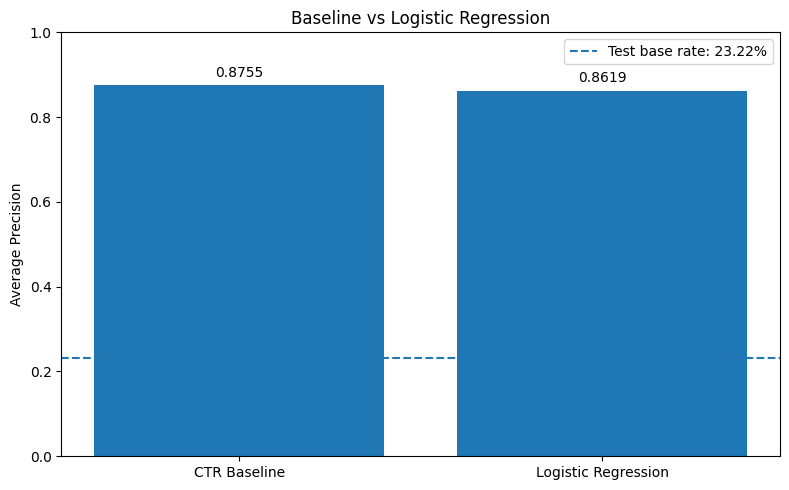

In [13]:
import matplotlib.pyplot as plt

chart_results = pd.DataFrame(
    {
        "Method": [
            "CTR Baseline",
            "Logistic Regression",
        ],
        "Average Precision": [
            baseline_ap,
            model_ap,
        ],
    }
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    chart_results["Method"],
    chart_results["Average Precision"],
)

plt.axhline(
    y=test_base_rate,
    linestyle="--",
    label=f"Test base rate: {test_base_rate:.2%}",
)

plt.title("Baseline vs Logistic Regression")
plt.ylabel("Average Precision")
plt.ylim(0, 1)
plt.legend()

for bar, value in zip(
    bars,
    chart_results["Average Precision"],
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center",
    )

plt.tight_layout()
plt.show()

In [14]:
# Final capstone notebook audit.

audit_results = {
    "Dataset contains rows": len(model_df) > 0,
    "Six February-only features used": len(feature_columns) == 6,
    "No missing model values": X.isna().sum().sum() == 0,
    "Fixed random seed used": RANDOM_STATE == 42,
    "Client overlap is zero": len(client_overlap) == 0,
    "Baseline evaluated": baseline_ap >= 0,
    "Logistic Regression evaluated": model_ap >= 0,
    "Same test rows used": len(baseline_scores) == len(model_scores),
    "Three failure cases reviewed": len(failure_examples) == 3,
    "Top-20 queue created": len(top_20_queue) == 20,
    "Privacy-safe identifiers used": "content_hash_id" in review_queue.columns,
}

print("Final capstone audit")
print("--------------------")

for check, passed in audit_results.items():
    print(f"{check}: {passed}")

assert all(audit_results.values())

print("\nAll capstone audit checks passed.")

Final capstone audit
--------------------
Dataset contains rows: True
Six February-only features used: True
No missing model values: True
Fixed random seed used: True
Client overlap is zero: True
Baseline evaluated: True
Logistic Regression evaluated: True
Same test rows used: True
Three failure cases reviewed: True
Top-20 queue created: True
Privacy-safe identifiers used: True

All capstone audit checks passed.
